In [55]:
import pandas as pd
import numpy as np

# Generate dummy healthcare data
np.random.seed(42) # for reproducibility

num_patients = 100

patient_ids = [f'P{i:03d}' for i in range(1, num_patients + 1)]
ages = np.random.randint(18, 90, size=num_patients).astype(float) # Convert to float to allow NaN
genders = np.random.choice(['Male', 'Female'], size=num_patients)
diagnoses = np.random.choice(['Flu', 'Cold', 'Fever', 'Diabetes', 'Hypertension', 'Asthma', 'Allergy'], size=num_patients)

# Introduce some missing values randomly
ages[np.random.choice(num_patients, 5, replace=False)] = np.nan
diagnoses[np.random.choice(num_patients, 3, replace=False)] = np.nan

healthcare_data = pd.DataFrame({
    'PatientID': patient_ids,
    'Age': ages,
    'Gender': genders,
    'Diagnosis': diagnoses
})

# Save to a CSV file
healthcare_data.to_csv('healthcare_data.csv', index=False)
print("Dummy 'healthcare_data.csv' created successfully.")

ValueError: cannot convert float NaN to integer

In [56]:
import pandas as pd

# 1. Load the dataset
df_healthcare = pd.read_csv('healthcare_data.csv')

# Display column names and data types
print("Column names and their data types:")
display(df_healthcare.info())

FileNotFoundError: [Errno 2] No such file or directory: 'healthcare_data.csv'

In [57]:
import pandas as pd

# Ensure df_healthcare is loaded if this cell is run independently
# if 'df_healthcare' not in locals():
#     df_healthcare = pd.read_csv('healthcare_data.csv')

# 2. Calculate and display the average age of the patients
# Handle potential missing values in 'Age' column by ignoring them for mean calculation
average_age = df_healthcare['Age'].mean()
print(f"The average age of the patients is: {average_age:.2f} years")

NameError: name 'df_healthcare' is not defined

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_healthcare is loaded if this cell is run independently
# if 'df_healthcare' not in locals():
#     df_healthcare = pd.read_csv('healthcare_data.csv')

# 3. Analyze the distribution of diagnoses
diagnosis_counts = df_healthcare['Diagnosis'].value_counts().reset_index()
diagnosis_counts.columns = ['Diagnosis', 'Count']

print("Distribution of Diagnoses:")
display(diagnosis_counts)

# Visualize the diagnosis distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Diagnosis', y='Count', data=diagnosis_counts, palette='viridis')
plt.title('Distribution of Patient Diagnoses')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NameError: name 'df_healthcare' is not defined

In [51]:
import pandas as pd
import numpy as np

# Generate dummy sales data
dates = pd.date_range(start='2022-01-01', periods=100, freq='D')
sales = np.random.randint(100, 1000, size=100).astype(float)

# Introduce some missing values randomly
sales[np.random.choice(100, 5, replace=False)] = np.nan

dummy_data = pd.DataFrame({'Date': dates, 'Sales': sales})

# Save to a CSV file
dummy_data.to_csv('sales_data.csv', index=False)
print("Dummy 'sales_data.csv' created successfully.")

Dummy 'sales_data.csv' created successfully.


In [52]:
import pandas as pd

# 1. Read the CSV file into a Pandas DataFrame
df = pd.read_csv('sales_data.csv')

# 2. Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

First 5 rows of the DataFrame:


,Date,Sales
0,2022-01-01,254.0
1,2022-01-02,228.0
2,2022-01-03,341.0
3,2022-01-04,723.0
4,2022-01-05,340.0


In [53]:
import pandas as pd

# Ensure df is loaded if this cell is run independently
# If df is not in current kernel state, load it: df = pd.read_csv('sales_data.csv')

# 3. Check for missing values
print("Missing values before handling:")
display(df.isnull().sum())

# Handle missing values (e.g., fill with the mean of the 'Sales' column)
# A more robust strategy might be interpolation or dropping rows, depending on data context
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

print("\nMissing values after handling:")
display(df.isnull().sum())

Missing values before handling:


,0
Date,0
Sales,5



Missing values after handling:


,0
Date,0
Sales,0


/tmp/ipykernel_516/689081544.py:16: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



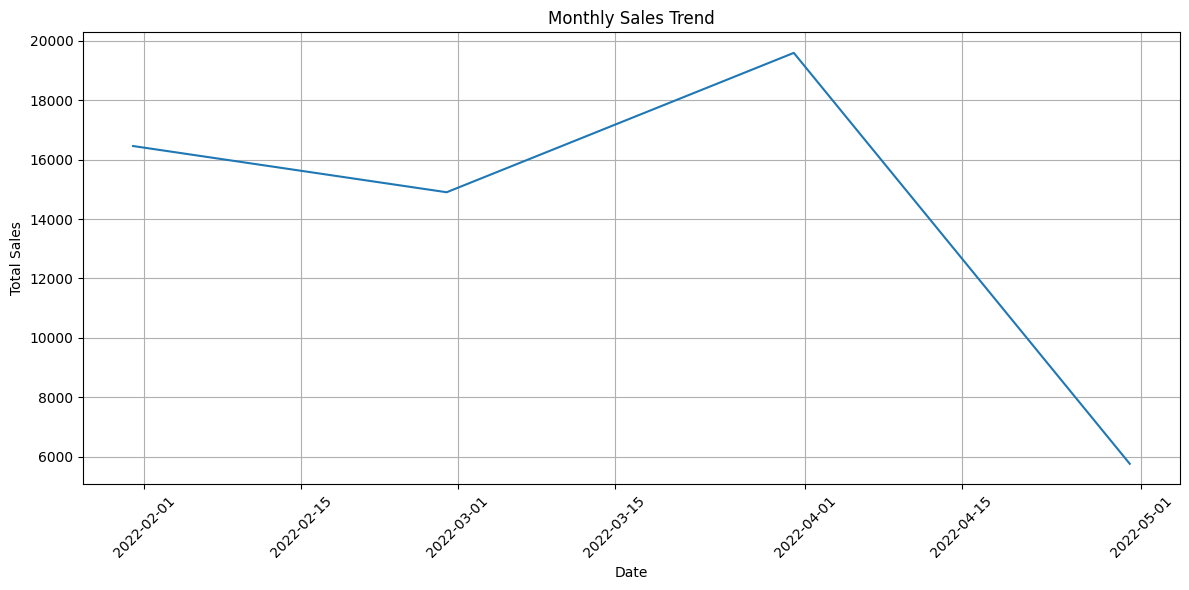

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded if this cell is run independently
# If df is not in current kernel state, load it: df = pd.read_csv('sales_data.csv')
# And handle missing values if not already done: df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as index for easier resampling
df.set_index('Date', inplace=True)

# Resample data to monthly frequency and sum sales
monthly_sales = df['Sales'].resample('M').sum()

# 4. Visualize the monthly sales trend using a line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()